# 4. Modelo base

Este capítulo cubre la sección 3 de la guía: regresión logística como modelo base, comparada contra
una línea base trivial (`DummyClassifier`), con entrenamiento mediante `Pipeline`, validación
cruzada estratificada, evaluación en el conjunto de prueba reservado, intervalos de confianza
bootstrap, curva de aprendizaje e interpretación de coeficientes.

La variable objetivo es `dificultad_cognitiva`, donde 1 significa alguna, mucha o no puede recordar
o concentrarse, y 0 significa ninguna dificultad, con una prevalencia del 20,6 %.

Se usa la partición definida en la sección 1.7, antes de cualquier preprocesamiento: 80 % de
entrenamiento (44 903) y 20 % de prueba (11 226), estratificada por objetivo y por año. El conjunto
de prueba no se usa para elegir hiperparámetros ni el umbral de decisión, se abre una sola vez, al
final del proceso.

Como la clase positiva es minoritaria, con un desbalance de 3,85 a 1, la métrica principal es la
PR-AUC o average precision, cuya referencia trivial es la prevalencia. Se reportan además el
ROC-AUC, el recall, la precisión, el F1 y el balanced accuracy de la clase positiva, junto con el
Brier score y la curva de calibración. El accuracy se muestra una sola vez, en la comparación con la
línea base, para mostrar por qué no es una métrica informativa con clases desbalanceadas.


In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import joblib
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.calibration import calibration_curve
from src.preprocesamiento import construir_preprocesador

train, test = cargar_particiones()
X_tr, y_tr = train[PREDICTORAS], train[OBJETIVO].values
X_te, y_te = test[PREDICTORAS], test[OBJETIVO].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Entrenamiento: {len(X_tr):,} ({y_tr.mean():.2%} positivos) | Prueba: {len(X_te):,} ({y_te.mean():.2%} positivos)")

Entrenamiento: 44,903 (20.61% positivos) | Prueba: 11,226 (20.60% positivos)


## 3.1 Línea base trivial

Se usan dos clasificadores triviales que no miran las predictoras en absoluto:
- `prior`, que asigna a todos la probabilidad igual a la prevalencia del entrenamiento y predice
  siempre la clase mayoritaria, es decir 0.
- `stratified`, que predice al azar respetando la proporción de clases.


In [2]:
puntuaciones = {"PR-AUC": "average_precision", "ROC-AUC": "roc_auc", "F1": "f1", "Recall": "recall",
                "Balanced acc.": "balanced_accuracy", "Brier (neg.)": "neg_brier_score"}
filas = []
for estrategia in ["prior", "stratified"]:
    r = cross_validate(DummyClassifier(strategy=estrategia, random_state=SEED), X_tr, y_tr, cv=cv, scoring=puntuaciones)
    filas.append([f"Dummy ({estrategia})"] + [f"{r['test_' + k].mean():.3f} ± {r['test_' + k].std():.3f}" for k in puntuaciones])
cv_dummy = pd.DataFrame(filas, columns=["modelo"] + list(puntuaciones)).set_index("modelo")
display(cv_dummy)

,PR-AUC,ROC-AUC,F1,Recall,Balanced acc.,Brier (neg.)
modelo,,,,,,
Dummy (prior),0.206 ± 0.000,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,-0.164 ± 0.000
Dummy (stratified),0.205 ± 0.000,0.498 ± 0.001,0.201 ± 0.002,0.200 ± 0.002,0.498 ± 0.001,-0.327 ± 0.001


## 3.2 Regresión logística: entrenamiento con `Pipeline` y validación cruzada

El pipeline une el preprocesamiento de la sección 2.9 con la regresión logística con
regularización L2. Se buscan dos hiperparámetros con validación cruzada estratificada de 5
particiones sobre el entrenamiento, del mismo tipo que la partición usada para reservar el
conjunto de prueba:
- `C`, el inverso de la fuerza de regularización, probado entre 0,001 y 10.
- `class_weight`, sin ponderar o `balanced`, que pondera la clase minoritaria.

El criterio de selección es la PR-AUC media.


In [3]:
modelo = Pipeline([("pre", construir_preprocesador()),
                   ("lr", LogisticRegression(max_iter=5000, random_state=SEED))])
rejilla = {"lr__C": [0.001, 0.01, 0.1, 1, 10], "lr__class_weight": [None, "balanced"]}
busqueda = GridSearchCV(modelo, rejilla, cv=cv, n_jobs=-1, refit="PR-AUC", return_train_score=True,
                        scoring={"PR-AUC": "average_precision", "ROC-AUC": "roc_auc", "Brier": "neg_brier_score"})
busqueda.fit(X_tr, y_tr)

res = pd.DataFrame(busqueda.cv_results_)
tabla_cv = pd.DataFrame({
    "C": res["param_lr__C"].astype(float),
    "class_weight": res["param_lr__class_weight"].map(lambda v: "balanced" if v == "balanced" else "ninguno"),
    "PR-AUC (val.)": res["mean_test_PR-AUC"], "de PR-AUC": res["std_test_PR-AUC"],
    "PR-AUC (entr.)": res["mean_train_PR-AUC"], "ROC-AUC (val.)": res["mean_test_ROC-AUC"],
    "Brier (val.)": -res["mean_test_Brier"]}).sort_values("PR-AUC (val.)", ascending=False)
display(tabla_cv.style.hide(axis="index").format(precision=4).highlight_max(subset=["PR-AUC (val.)"], color="#fddbc7"))
print("Mejores hiperparámetros:", busqueda.best_params_)
mejor = busqueda.best_estimator_

C,class_weight,PR-AUC (val.),de PR-AUC,PR-AUC (entr.),ROC-AUC (val.),Brier (val.)
1.0000,ninguno,0.5193,0.0104,0.5213,0.7934,0.1308
10.0000,ninguno,0.5193,0.0104,0.5214,0.7934,0.1308
0.1000,ninguno,0.5189,0.0104,0.5209,0.7934,0.1308
10.0000,balanced,0.5186,0.0106,0.5204,0.7935,0.1826
1.0000,balanced,0.5186,0.0106,0.5203,0.7935,0.1826
0.1000,balanced,0.5182,0.0104,0.5199,0.7934,0.1827
0.0100,ninguno,0.5134,0.0100,0.5151,0.7914,0.1315
0.0100,balanced,0.5132,0.0101,0.5148,0.7918,0.1840
0.0010,balanced,0.4905,0.0097,0.4913,0.7808,0.1944
0.0010,ninguno,0.4874,0.0093,0.4881,0.7783,0.1382


Mejores hiperparámetros: {'lr__C': 1, 'lr__class_weight': None}


La línea base trivial obtiene en validación cruzada una PR-AUC de 0,206, igual a la prevalencia, y
un ROC-AUC de 0,50, tal como se espera de un modelo que no usa las predictoras. La regresión
logística alcanza una PR-AUC de validación de 0,519 ± 0,010 y un ROC-AUC de 0,793, es decir más del
doble de la PR-AUC trivial.

Sobre los hiperparámetros, la regularización tiene un desempeño prácticamente idéntico para C entre
0,1 y 10, y solo empeora con una regularización muy fuerte (C = 0,001). Con más de 1 000
observaciones por parámetro, la regularización apenas hace falta, así que se elige C = 1. En cuanto
a la ponderación de clases, usar `balanced` no mejora la PR-AUC (0,5186 frente a 0,5193) pero
empeora bastante la calibración, con un Brier de 0,183 frente a 0,131, porque infla artificialmente
las probabilidades de la clase positiva. Por eso se prefiere el modelo sin ponderar, y el desbalance
se maneja más bien con el umbral de decisión (sección 3.3). Finalmente, no hay sobreajuste: la
PR-AUC de entrenamiento (0,521) es casi igual a la de validación (0,519).


## 3.3 Umbral de decisión

La regresión logística entrega probabilidades, y para clasificar hace falta fijar un umbral. El
umbral por defecto de 0,5 no es óptimo con clases desbalanceadas, así que se elige el umbral que
maximiza el F1 en las predicciones fuera de partición, es decir out-of-fold, del entrenamiento, de
modo que el conjunto de prueba no interviene para nada en esta decisión.


Umbral que maximiza el F1 out-of-fold: 0.246 (F1 = 0.529; precisión = 0.457; recall = 0.627)
F1 out-of-fold con el umbral por defecto de 0,5: 0.391


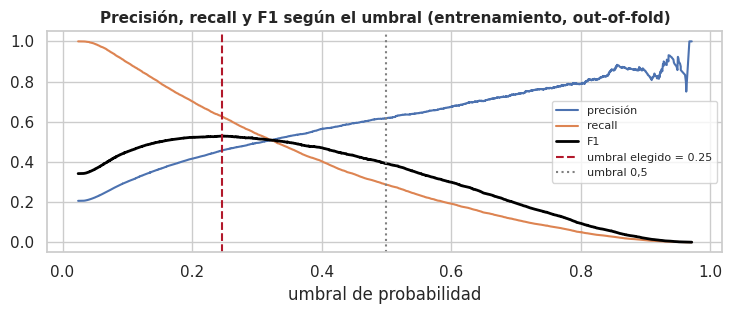

In [4]:
p_oof = cross_val_predict(mejor, X_tr, y_tr, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, umbrales = precision_recall_curve(y_tr, p_oof)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
umbral = float(umbrales[np.argmax(f1s)])
print(f"Umbral que maximiza el F1 out-of-fold: {umbral:.3f} (F1 = {f1s.max():.3f}; "
      f"precisión = {prec[np.argmax(f1s)]:.3f}; recall = {rec[np.argmax(f1s)]:.3f})")
print(f"F1 out-of-fold con el umbral por defecto de 0,5: {f1_score(y_tr, p_oof >= 0.5):.3f}")

fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.plot(umbrales, prec[:-1], label="precisión"); ax.plot(umbrales, rec[:-1], label="recall")
ax.plot(umbrales, f1s, label="F1", lw=2, color="black")
ax.axvline(umbral, ls="--", color="#b2182b", label=f"umbral elegido = {umbral:.2f}")
ax.axvline(0.5, ls=":", color="gray", label="umbral 0,5")
ax.set_xlabel("umbral de probabilidad"); ax.set_title("Precisión, recall y F1 según el umbral (entrenamiento, out-of-fold)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Con el umbral por defecto de 0,5, el F1 out-of-fold sería de solo 0,391, porque el modelo casi
nunca asigna probabilidades tan altas a una clase que representa apenas el 20 % de los casos. El
umbral que maximiza el F1 en entrenamiento es 0,246, con una precisión de 0,457 y un recall de
0,627. Tiene sentido con la prevalencia observada, porque con clases desbalanceadas el umbral óptimo
suele estar cerca de la proporción de positivos. Este umbral se fija antes de mirar siquiera el
conjunto de prueba.

La gráfica muestra el compromiso de siempre: bajar el umbral detecta más casos, sube el recall, pero
a costa de más falsas alarmas, baja la precisión. En un uso de tamizaje, donde perder un caso real es
más costoso que evaluar de más a alguien sano, podría elegirse un umbral todavía menor, aunque esa
decisión depende del contexto de uso y no solo de la estadística.


## 3.4 Evaluación en el conjunto de prueba y comparación con la línea base

Aquí se abre por primera y única vez el conjunto de prueba. Los intervalos de confianza del 95 % se
obtienen con bootstrap no paramétrico, con 1 000 remuestreos del conjunto de prueba y el método de
percentiles.


In [5]:
dummy_prior = DummyClassifier(strategy="prior").fit(X_tr, y_tr)
dummy_strat = DummyClassifier(strategy="stratified", random_state=SEED).fit(X_tr, y_tr)
p_lr = mejor.predict_proba(X_te)[:, 1]
modelos_prob = {"Dummy (prior)": dummy_prior.predict_proba(X_te)[:, 1],
                "Dummy (stratified)": dummy_strat.predict_proba(X_te)[:, 1],
                "Regresión logística": p_lr}
modelos_pred = {"Dummy (prior)": dummy_prior.predict(X_te), "Dummy (stratified)": dummy_strat.predict(X_te),
                "Regresión logística": (p_lr >= umbral).astype(int)}

def metricas(y, p, yhat):
    return {"PR-AUC": average_precision_score(y, p), "ROC-AUC": roc_auc_score(y, p) if len(set(p)) > 1 else 0.5,
            "Recall": recall_score(y, yhat, zero_division=0), "Precisión": precision_score(y, yhat, zero_division=0),
            "F1": f1_score(y, yhat, zero_division=0), "Balanced acc.": balanced_accuracy_score(y, yhat),
            "Brier": brier_score_loss(y, p), "Accuracy": accuracy_score(y, yhat)}

rng = np.random.RandomState(SEED)
B = 1000
idx_boot = [rng.randint(0, len(y_te), len(y_te)) for _ in range(B)]
tabla, boots = {}, {}
for nombre in modelos_prob:
    p, yhat = modelos_prob[nombre], modelos_pred[nombre]
    punto = metricas(y_te, p, yhat)
    bs = pd.DataFrame([metricas(y_te[i], p[i], yhat[i]) for i in idx_boot])
    boots[nombre] = bs
    tabla[nombre] = {k: f"{v:.3f} [{bs[k].quantile(0.025):.3f}–{bs[k].quantile(0.975):.3f}]" for k, v in punto.items()}
tabla = pd.DataFrame(tabla)
display(tabla.style.set_caption("Métricas en el conjunto de prueba: valor [IC 95 % bootstrap]"))

dif = boots["Regresión logística"] - boots["Dummy (stratified)"]
print("Mejora de la regresión logística sobre el Dummy estratificado (IC 95 % bootstrap):")
for k in ["PR-AUC", "ROC-AUC", "F1", "Recall", "Balanced acc."]:
    print(f"   {k}: +{dif[k].mean():.3f} [{dif[k].quantile(0.025):.3f}–{dif[k].quantile(0.975):.3f}]")

,Dummy (prior),Dummy (stratified),Regresión logística
PR-AUC,0.206 [0.199–0.214],0.208 [0.200–0.217],0.538 [0.517–0.561]
ROC-AUC,0.500 [0.500–0.500],0.507 [0.497–0.517],0.804 [0.794–0.814]
Recall,0.000 [0.000–0.000],0.214 [0.197–0.234],0.637 [0.619–0.657]
Precisión,0.000 [0.000–0.000],0.217 [0.199–0.237],0.461 [0.445–0.480]
F1,0.000 [0.000–0.000],0.216 [0.199–0.234],0.535 [0.520–0.552]
Balanced acc.,0.500 [0.500–0.500],0.507 [0.497–0.517],0.722 [0.712–0.733]
Brier,0.164 [0.159–0.168],0.321 [0.313–0.330],0.128 [0.124–0.132]
Accuracy,0.794 [0.786–0.801],0.679 [0.670–0.687],0.772 [0.764–0.780]


Mejora de la regresión logística sobre el Dummy estratificado (IC 95 % bootstrap):
   PR-AUC: +0.330 [0.309–0.351]
   ROC-AUC: +0.297 [0.284–0.311]
   F1: +0.320 [0.298–0.342]
   Recall: +0.423 [0.397–0.448]
   Balanced acc.: +0.215 [0.201–0.230]


En el conjunto de prueba, la regresión logística obtiene una PR-AUC de 0,538 [0,517-0,561], frente
a 0,206 de la línea base, es decir 2,6 veces la referencia trivial. El ROC-AUC es de 0,804
[0,794-0,814], lo que significa que si se toma al azar una persona con dificultad cognitiva y otra
sin ella, el modelo le asigna mayor probabilidad a la primera el 80 % de las veces. Con el umbral
elegido, el recall es de 0,637 y la precisión de 0,461: el modelo detecta casi dos de cada tres
casos, y cerca de la mitad de sus alertas resultan correctas, frente a una de cada cinco que se
obtendría por azar. El F1 es de 0,535 y el balanced accuracy de 0,722.

La mejora sobre el Dummy estratificado es clara y significativa en todas las métricas, por ejemplo
+0,330 en PR-AUC, con un IC 95 % de 0,309 a 0,351 que no incluye el cero. Las métricas de prueba son
además coherentes con las de validación cruzada (PR-AUC 0,519 ± 0,010): la pequeña diferencia está
dentro de la variabilidad esperada, lo que confirma que el modelo generaliza razonablemente bien.

Aquí aparece la trampa clásica del accuracy: el Dummy mayoritario obtiene un accuracy de 0,794,
mayor que el de la regresión logística (0,772), pero sin detectar un solo caso, con recall igual a
0. Es exactamente el escenario que advierte la guía, y la razón por la que el accuracy no se usa
para decidir nada aquí.

Todas las métricas quedan por debajo de 0,90, con un margen amplio de mejora, lo que hace de este un
problema adecuado para comparar modelos más complejos en las siguientes entregas.


VP = 1,474 | FN = 839 | FP = 1,723 | VN = 7,190 | especificidad = 0.807 | VPN = 0.896 | positivos predichos = 3,197 (28.5% del total)


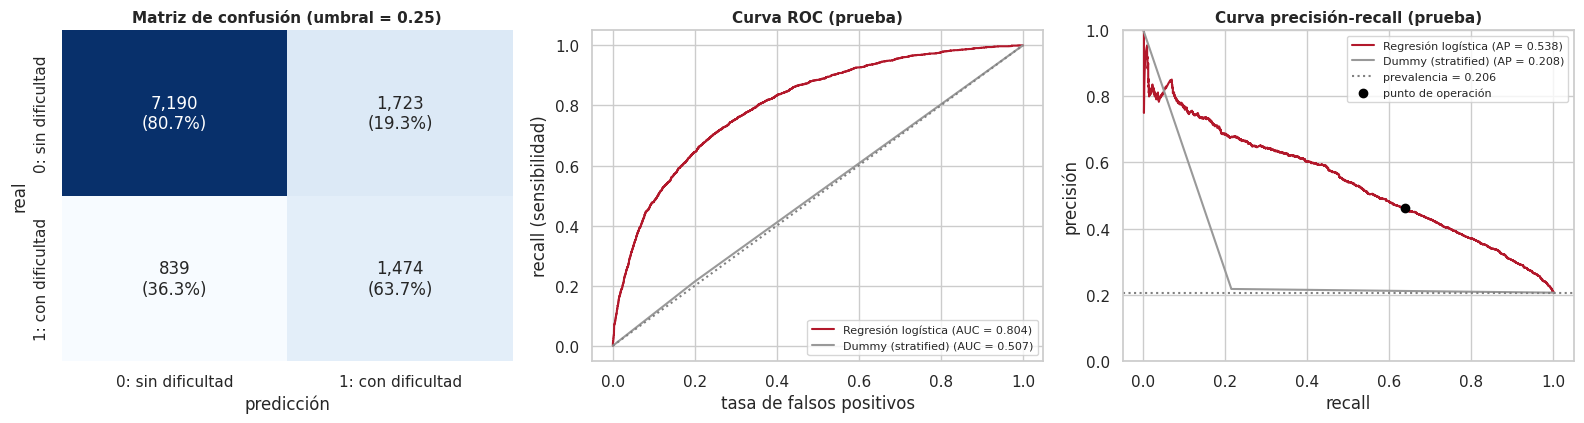

In [6]:
cm = confusion_matrix(y_te, modelos_pred["Regresión logística"])
vn, fp, fn, vp = cm.ravel()
print(f"VP = {vp:,} | FN = {fn:,} | FP = {fp:,} | VN = {vn:,} | especificidad = {vn / (vn + fp):.3f} | "
      f"VPN = {vn / (vn + fn):.3f} | positivos predichos = {vp + fp:,} ({(vp + fp) / len(y_te):.1%} del total)")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
etq = ["0: sin dificultad", "1: con dificultad"]
sns.heatmap(cm, annot=np.array([[f"{v:,}\n({v / cm[i].sum():.1%})" for v in fila] for i, fila in enumerate(cm)]),
            fmt="", cmap="Blues", cbar=False, xticklabels=etq, yticklabels=etq, ax=axes[0])
axes[0].set_xlabel("predicción"); axes[0].set_ylabel("real"); axes[0].set_title(f"Matriz de confusión (umbral = {umbral:.2f})")

for nombre, color in [("Regresión logística", "#b2182b"), ("Dummy (stratified)", "#999999")]:
    fpr, tpr, _ = roc_curve(y_te, modelos_prob[nombre])
    axes[1].plot(fpr, tpr, color=color, label=f"{nombre} (AUC = {roc_auc_score(y_te, modelos_prob[nombre]):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, modelos_prob[nombre])
    axes[2].plot(rc, pr, color=color, label=f"{nombre} (AP = {average_precision_score(y_te, modelos_prob[nombre]):.3f})")
axes[1].plot([0, 1], [0, 1], ls=":", color="gray"); axes[1].set_xlabel("tasa de falsos positivos"); axes[1].set_ylabel("recall (sensibilidad)")
axes[1].set_title("Curva ROC (prueba)"); axes[1].legend(fontsize=8, loc="lower right")
axes[2].axhline(y_te.mean(), ls=":", color="gray", label=f"prevalencia = {y_te.mean():.3f}")
i_op = np.argmin(np.abs(precision_recall_curve(y_te, p_lr)[2] - umbral))
axes[2].scatter(recall_score(y_te, p_lr >= umbral), precision_score(y_te, p_lr >= umbral), color="black", zorder=5,
                label="punto de operación")
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precisión"); axes[2].set_title("Curva precisión-recall (prueba)")
axes[2].legend(fontsize=8); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

De los 2 313 adultos con dificultad cognitiva en el conjunto de prueba, el modelo identifica
correctamente a 1 474 (63,7 %) y no detecta a 839. De los 8 913 sin dificultad, clasifica bien a
7 190, con una especificidad de 0,807, y genera 1 723 falsas alarmas. En total marca como positivos
al 28,5 % de los adultos. El valor predictivo negativo es de 0,896, es decir que cuando el modelo
dice que no hay dificultad, acierta en casi 9 de cada 10 casos, lo que lo hace bastante útil para
descartar.

La curva ROC está claramente por encima de la diagonal del azar en todo el rango, sin cruces con la
línea base. La curva de precisión-recall es la más informativa cuando hay desbalance: la precisión
parte cerca de 0,8 para los adultos con mayor probabilidad predicha y va cayendo a medida que se
exige más recall, siempre muy por encima de la línea de la prevalencia (0,206). El punto marcado en
la gráfica corresponde al compromiso elegido.


### 3.4.1 Calibración

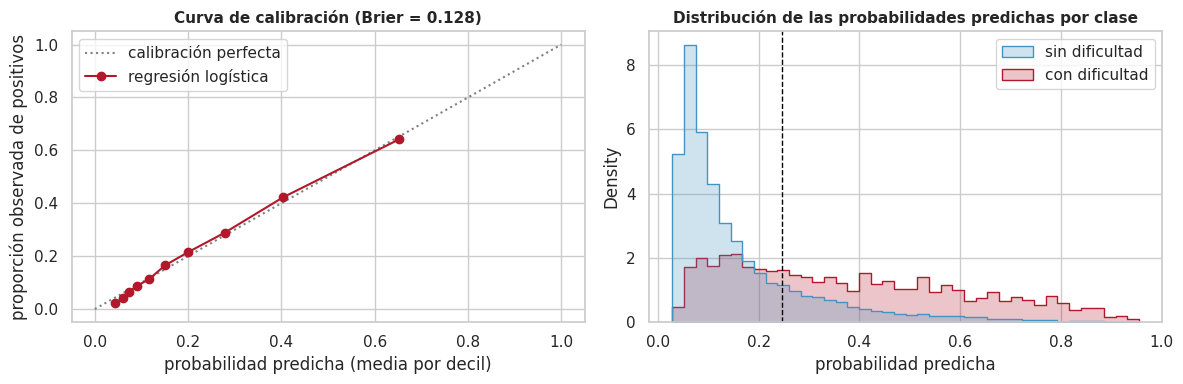

Brier del modelo = 0.1277; Brier de referencia (prevalencia) = 0.1636; Brier skill score = 0.219
Probabilidad media predicha = 0.207 vs. prevalencia observada = 0.206


,0,1,2,3,4,5,6,7,8,9
prob. media predicha,0.0440,0.0590,0.0730,0.0910,0.1160,0.1500,0.2000,0.2780,0.4040,0.6520
proporción observada,0.0230,0.0400,0.0650,0.0880,0.1120,0.1650,0.2150,0.2890,0.4220,0.6410


In [7]:
frac_pos, prob_media = calibration_curve(y_te, p_lr, n_bins=10, strategy="quantile")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([0, 1], [0, 1], ls=":", color="gray", label="calibración perfecta")
axes[0].plot(prob_media, frac_pos, "o-", color="#b2182b", label="regresión logística")
axes[0].set_xlabel("probabilidad predicha (media por decil)"); axes[0].set_ylabel("proporción observada de positivos")
axes[0].set_title(f"Curva de calibración (Brier = {brier_score_loss(y_te, p_lr):.3f})"); axes[0].legend()
sns.histplot(x=p_lr, hue=np.where(y_te == 1, "con dificultad", "sin dificultad"), bins=40, stat="density",
             common_norm=False, element="step", ax=axes[1], palette={"con dificultad": "#b2182b", "sin dificultad": "#4393c3"})
axes[1].axvline(umbral, ls="--", color="black", lw=1); axes[1].set_xlabel("probabilidad predicha")
axes[1].set_title("Distribución de las probabilidades predichas por clase")
plt.tight_layout(); plt.show()

brier_ref = brier_score_loss(y_te, np.full_like(p_lr, y_tr.mean()))
print(f"Brier del modelo = {brier_score_loss(y_te, p_lr):.4f}; Brier de referencia (prevalencia) = {brier_ref:.4f}; "
      f"Brier skill score = {1 - brier_score_loss(y_te, p_lr) / brier_ref:.3f}")
print(f"Probabilidad media predicha = {p_lr.mean():.3f} vs. prevalencia observada = {y_te.mean():.3f}")
display(pd.DataFrame({"prob. media predicha": prob_media, "proporción observada": frac_pos}).T.round(3))

El modelo está bien calibrado: la curva de calibración sigue de cerca la diagonal, y la
probabilidad media predicha (0,207) coincide con la prevalencia observada (0,206). En el decil de
mayor riesgo, el modelo predice en promedio 0,652 y la proporción observada es 0,641. Solo en el
decil más bajo sobreestima levemente el riesgo, con 0,044 predicho frente a 0,023 observado, una
diferencia pequeña en términos absolutos.

El Brier score es de 0,128, frente a 0,164 de predecir siempre la prevalencia, lo que equivale a una
mejora relativa, o Brier skill score, del 21,9 %. El histograma ayuda a entender por qué el
desempeño es moderado: las dos clases se superponen bastante, aunque los adultos con dificultad
cognitiva se concentran en las probabilidades más altas. Esta buena calibración es importante para
el uso que se le quiere dar al modelo, porque permite interpretar las probabilidades directamente
como un riesgo estimado.


### 3.4.2 Diagnóstico de residuos

La guía pide revisar si los residuos conservan alguna estructura. Como el dataset no tiene
componente temporal ni espacial, no aplican la ACF ni el I de Moran de residuos (sección 2.6-2.8).
El equivalente para un clasificador es verificar que el residuo medio, entendido como observado
menos predicho, sea cercano a cero en los subgrupos relevantes. Un residuo medio que se aleje de
cero de forma sistemática en algún subgrupo indicaría información estructural que el modelo no
está capturando.


In [8]:
diag = test.assign(p=p_lr, residuo=y_te - p_lr, grupo_edad=pd.cut(test["edad"], [17, 34, 49, 64, 74, 85]))
filas = []
for var in ["anio", "trimestre", "sexo", "grupo_edad", "acv", "frecuencia_depresion"]:
    for nivel, g in diag.groupby(var, observed=True):
        ic = 1.96 * g["residuo"].std() / np.sqrt(len(g))
        auc = roc_auc_score(g[OBJETIVO], g["p"]) if g[OBJETIVO].nunique() > 1 else np.nan
        filas.append([var, str(nivel), len(g), g[OBJETIVO].mean(), g["p"].mean(), g["residuo"].mean(), ic, auc,
                      average_precision_score(g[OBJETIVO], g["p"])])
res_sub = pd.DataFrame(filas, columns=["variable", "nivel", "n", "observado", "predicho", "residuo medio", "± IC95",
                                       "ROC-AUC", "PR-AUC"])
display(res_sub.style.hide(axis="index").format({"observado": "{:.3f}", "predicho": "{:.3f}", "residuo medio": "{:+.3f}",
                                                 "± IC95": "{:.3f}", "ROC-AUC": "{:.3f}", "PR-AUC": "{:.3f}"})
        .background_gradient(subset=["residuo medio"], cmap="RdBu", vmin=-0.05, vmax=0.05))

variable,nivel,n,observado,predicho,residuo medio,± IC95,ROC-AUC,PR-AUC
anio,2022,5431,0.204,0.205,-0.001,0.009,0.805,0.535
anio,2023,5795,0.208,0.208,-0.000,0.009,0.803,0.542
trimestre,1,2757,0.209,0.204,+0.005,0.013,0.807,0.543
trimestre,2,2710,0.205,0.204,+0.001,0.014,0.797,0.534
trimestre,3,2898,0.198,0.208,-0.010,0.013,0.800,0.537
trimestre,4,2861,0.211,0.210,+0.001,0.013,0.810,0.543
sexo,Hombre,5104,0.180,0.184,-0.005,0.009,0.800,0.495
sexo,Mujer,6121,0.228,0.225,+0.003,0.009,0.803,0.565
grupo_edad,"(17, 34]",2307,0.174,0.182,-0.007,0.014,0.800,0.506
grupo_edad,"(34, 49]",2528,0.136,0.149,-0.013,0.012,0.817,0.485


El residuo medio es cercano a cero en casi todos los subgrupos, y sus intervalos incluyen el cero.
Por año y trimestre, los residuos van de -0,010 a +0,005, sin ninguna estructura temporal, y el
modelo funciona igual en 2022 y en 2023 (ROC-AUC de 0,805 y 0,803). Por sexo, el modelo está
calibrado en ambos grupos, con residuos de -0,005 y +0,003, y un ROC-AUC casi igual (0,800 y 0,803).

Aparecen sin embargo dos señales que conviene anotar como información estructural que el modelo
todavía no captura. La primera es en los mayores de 75 años: el modelo subestima levemente el
riesgo, con un residuo de +0,024 en el límite de la significación, y discrimina peor a partir de
los 65 años, con un ROC-AUC de 0,74 y 0,73 frente a 0,80-0,82 en menores de 65. En los adultos
mayores, la dificultad cognitiva parece depender menos de los factores que el modelo está midiendo.
La segunda es en quienes tienen antecedente de ACV, donde el ROC-AUC cae a 0,707 dentro de ese
grupo, algo coherente con la interacción entre ACV y edad detectada en el EDA (sección 2.3.4), que
un modelo aditivo simplemente no puede representar.

Ambas señales apuntan en la misma dirección: los modelos de las siguientes entregas deberían incluir
interacciones, o usar métodos que las aprendan por sí solos, como árboles o boosting.


## 3.5 Curva de aprendizaje

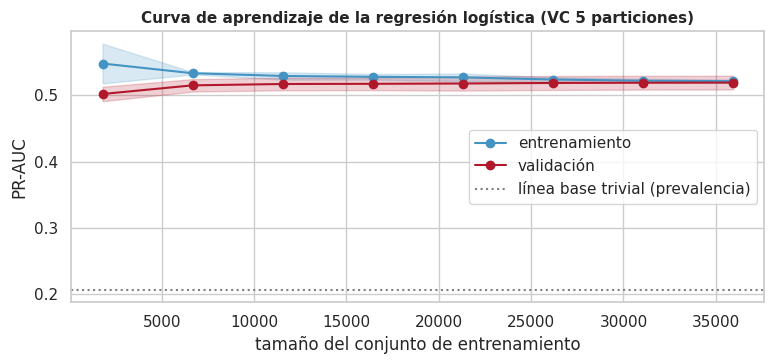

n entrenamiento,PR-AUC entr.,PR-AUC val.,brecha
1796,0.5480,0.5020,0.0460
6671,0.5333,0.5151,0.0183
11546,0.5292,0.5171,0.0121
16421,0.5279,0.5174,0.0106
21296,0.5271,0.5178,0.0093
26171,0.5239,0.5187,0.0052
31046,0.5220,0.5190,0.0029
35922,0.5214,0.5192,0.0021


In [9]:
tamanos, sc_tr, sc_val = learning_curve(mejor, X_tr, y_tr, cv=cv, scoring="average_precision",
                                        train_sizes=np.linspace(0.05, 1.0, 8), n_jobs=-1, shuffle=True, random_state=SEED)
fig, ax = plt.subplots(figsize=(8, 3.8))
for sc, etiqueta, color in [(sc_tr, "entrenamiento", "#4393c3"), (sc_val, "validación", "#b2182b")]:
    ax.plot(tamanos, sc.mean(axis=1), "o-", color=color, label=etiqueta)
    ax.fill_between(tamanos, sc.mean(axis=1) - sc.std(axis=1), sc.mean(axis=1) + sc.std(axis=1), alpha=0.2, color=color)
ax.axhline(y_tr.mean(), ls=":", color="gray", label="línea base trivial (prevalencia)")
ax.set_xlabel("tamaño del conjunto de entrenamiento"); ax.set_ylabel("PR-AUC"); ax.legend()
ax.set_title("Curva de aprendizaje de la regresión logística (VC 5 particiones)")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"n entrenamiento": tamanos, "PR-AUC entr.": sc_tr.mean(axis=1), "PR-AUC val.": sc_val.mean(axis=1),
                      "brecha": sc_tr.mean(axis=1) - sc_val.mean(axis=1)}).style.hide(axis="index").format(precision=4))

La curva de aprendizaje muestra dos cosas: que el tamaño de la muestra es más que suficiente y que
no hay sobreajuste. Con solo 1 800 adultos, la brecha entre entrenamiento y validación es de 0,046,
y con los 35 900 de cada partición de entrenamiento completa se reduce a 0,002. La PR-AUC de
validación se estabiliza en torno a 0,519 desde unos 16 000 adultos, así que añadir más datos del
mismo tipo casi no mejoraría el modelo.

Las dos curvas convergen en un valor moderado, y ese es justamente el patrón de un modelo limitado
por sesgo y no por varianza: la regresión logística aditiva ya extrajo todo lo que puede de estas
variables. Para mejorar quedan dos caminos, modelos más flexibles que capturen interacciones y no
linealidades, o nuevas variables, por ejemplo sueño, actividad física o ansiedad. Esto es justamente
lo que justifica la siguiente etapa del proyecto.


## 3.6 Interpretación de los coeficientes

Los coeficientes de la regresión logística se expresan como odds ratios: un OR de 2 indica que las
odds de reportar dificultad cognitiva se duplican respecto a la categoría de referencia, manteniendo
constantes las demás variables. Para obtener intervalos de confianza se reajusta el mismo modelo sin
penalización con `statsmodels` sobre la matriz preprocesada del entrenamiento. Con la regularización
elegida, ambos conjuntos de coeficientes prácticamente coinciden, como se verifica más abajo.


In [10]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

pre_fit = mejor.named_steps["pre"]
nombres = [n.split("__", 1)[1] for n in pre_fit.get_feature_names_out()]
Xm = pd.DataFrame(pre_fit.transform(X_tr), columns=nombres)
logit = sm.Logit(y_tr, sm.add_constant(Xm)).fit(disp=0)
coef_sk = pd.Series(mejor.named_steps["lr"].coef_[0], index=nombres)
print(f"Correlación entre coeficientes penalizados (sklearn) y no penalizados (statsmodels): "
      f"{np.corrcoef(coef_sk, logit.params[nombres])[0, 1]:.4f}")

ors = pd.DataFrame({"OR": np.exp(logit.params), "IC95% inf": np.exp(logit.conf_int()[0]),
                    "IC95% sup": np.exp(logit.conf_int()[1]), "p": logit.pvalues}).drop(index="const")
ors = ors[~ors.index.str.startswith(("edad_sp", "missingindicator"))]
ors["p (Holm)"] = multipletests(ors["p"], method="holm")[1]
display(ors.sort_values("OR", ascending=False).style.format({"OR": "{:.2f}", "IC95% inf": "{:.2f}", "IC95% sup": "{:.2f}",
                                                             "p": "{:.1e}", "p (Holm)": "{:.1e}"})
        .background_gradient(subset=["OR"], cmap="RdBu_r", vmin=0.3, vmax=3.0))

Correlación entre coeficientes penalizados (sklearn) y no penalizados (statsmodels): 0.9977


,OR,IC95% inf,IC95% sup,p,p (Holm)
frecuencia_depresion_Diaria,4.93,4.37,5.55,8.5e-150,2.2e-148
frecuencia_depresion_Semanal,3.61,3.26,4.01,5.7e-130,1.4e-128
frecuencia_depresion_Mensual,2.94,2.67,3.23,1.8e-109,3.9e-108
dificultad_auditiva_Mucha o no puede,2.61,2.20,3.10,7.4e-28,1.5e-26
dificultad_visual_Mucha o no puede,2.47,2.07,2.95,6.0e-24,1.1e-22
dificultad_auditiva_Alguna,2.43,2.28,2.59,4.1e-164,1.1e-162
depresion_dx_Sí,2.20,2.05,2.35,1.3e-110,3.0e-109
dificultad_visual_Alguna,2.10,1.98,2.23,1.4e-125,3.3e-124
frecuencia_depresion_Pocas veces al año,1.91,1.79,2.03,2.5e-86,5.2e-85
acv_Sí,1.69,1.50,1.90,1.6e-17,2.5e-16


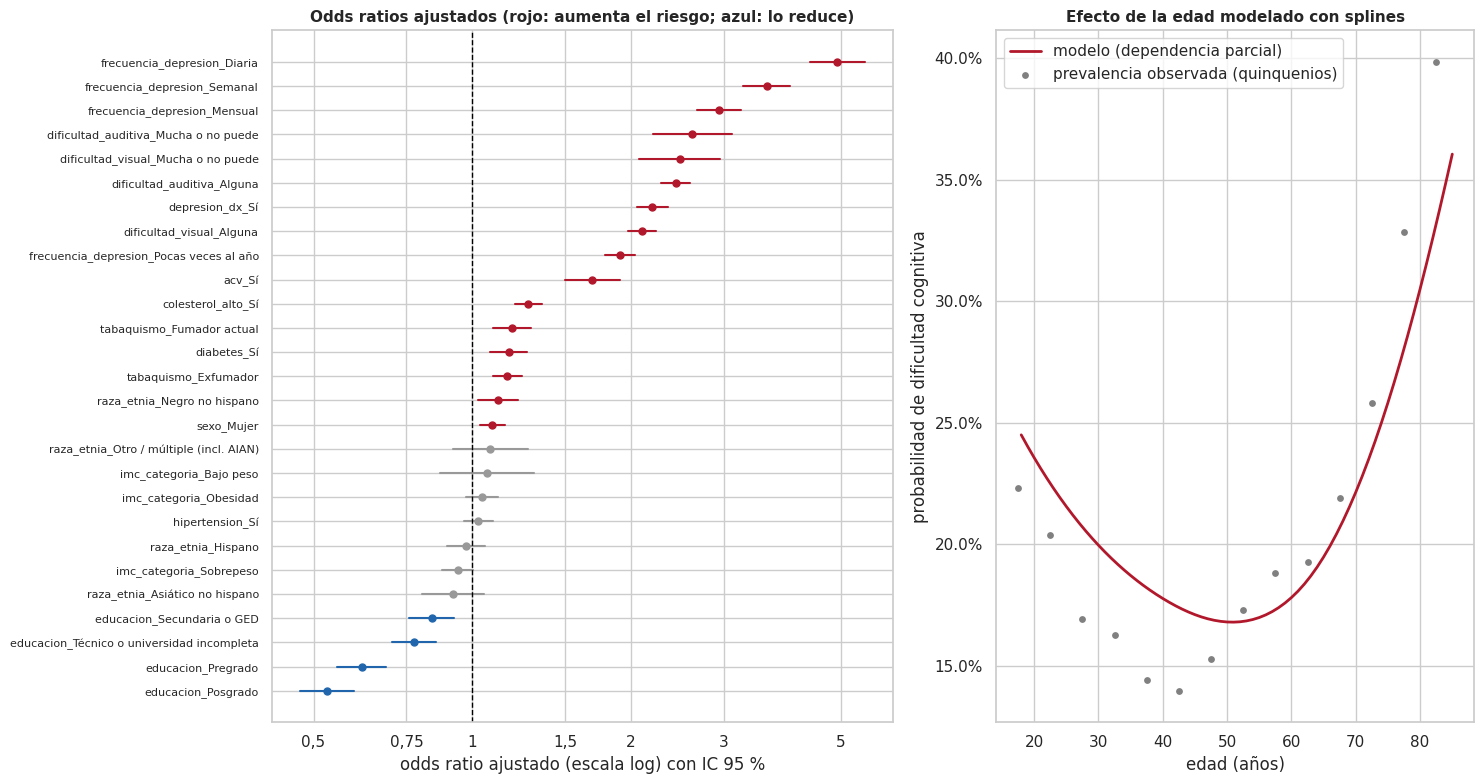

Probabilidad media predicha: 0.245 a los 18 años; mínimo 0.168 a los 51 años; 0.361 a los 85 años


In [11]:
orden = ors.sort_values("OR")
fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1.3, 1]})
colores = np.where(orden["IC95% inf"] > 1, "#b2182b", np.where(orden["IC95% sup"] < 1, "#2166ac", "#999999"))
for i, (nombre_v, fila) in enumerate(orden.iterrows()):
    axes[0].plot([fila["IC95% inf"], fila["IC95% sup"]], [i, i], color=colores[i], lw=1.5)
    axes[0].scatter(fila["OR"], i, color=colores[i], zorder=3, s=25)
axes[0].axvline(1, ls="--", color="black", lw=1); axes[0].set_xscale("log")
axes[0].set_xticks([0.5, 0.75, 1, 1.5, 2, 3, 5], ["0,5", "0,75", "1", "1,5", "2", "3", "5"]); axes[0].minorticks_off()
axes[0].set_yticks(range(len(orden)), orden.index, fontsize=8)
axes[0].set_xlabel("odds ratio ajustado (escala log) con IC 95 %")
axes[0].set_title("Odds ratios ajustados (rojo: aumenta el riesgo; azul: lo reduce)")

# Efecto de la edad (dependencia parcial): probabilidad media predicha al fijar la edad
muestra = X_tr.sample(4000, random_state=SEED)
edades = np.arange(18, 86)
pd_edad = [mejor.predict_proba(muestra.assign(edad=float(e)))[:, 1].mean() for e in edades]
axes[1].plot(edades, pd_edad, color="#b2182b", lw=2, label="modelo (dependencia parcial)")
obs = train.groupby(pd.cut(train["edad"], range(15, 90, 5)), observed=True)[OBJETIVO].mean()
axes[1].scatter([i.mid for i in obs.index], obs.values, color="gray", s=15, label="prevalencia observada (quinquenios)")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); axes[1].legend()
axes[1].set_xlabel("edad (años)"); axes[1].set_ylabel("probabilidad de dificultad cognitiva")
axes[1].set_title("Efecto de la edad modelado con splines")
plt.tight_layout(); plt.show()
print(f"Probabilidad media predicha: {pd_edad[0]:.3f} a los 18 años; mínimo {min(pd_edad):.3f} a los "
      f"{edades[int(np.argmin(pd_edad))]} años; {pd_edad[-1]:.3f} a los 85 años")

Los coeficientes penalizados y no penalizados son prácticamente idénticos, con una correlación de
0,998, así que los intervalos de `statsmodels` son válidos para el modelo elegido. Todos los OR que
siguen están ajustados por las demás variables.

Los síntomas depresivos son el factor más fuerte, con un gradiente dosis-respuesta muy nítido.
Frente a quien nunca se siente deprimido, las odds de dificultad cognitiva son 1,9 veces mayores con
síntomas pocas veces al año, 2,9 veces con síntomas mensuales, 3,6 con semanales y 4,9 con diarios.
El diagnóstico de depresión añade además un OR de 2,2, independiente de los síntomas actuales.

Las pérdidas sensoriales también pesan bastante: la dificultad auditiva tiene un OR de 2,4 con
alguna dificultad y 2,6 con mucha, y la visual de 2,1 y 2,5. Esto va en línea con la Comisión Lancet,
que considera la pérdida auditiva uno de los factores modificables de mayor peso.

El ACV, que es la exposición de interés de este proyecto, queda con un OR ajustado de 1,69
[1,50-1,90]. Es menor que el OR crudo (3,36) y que el ajustado solo por edad (2,52), porque parte de
su asociación se comparte con la depresión, las pérdidas sensoriales y los factores vasculares. Aun
así sigue siendo un factor independiente y significativo.

Los factores vasculares y de estilo de vida aumentan el riesgo de forma más modesta: colesterol
alto (1,28), tabaquismo actual (1,19) y pasado (1,17) y diabetes (1,17). La hipertensión, en cambio,
deja de ser significativa al ajustar (OR 1,03; IC 0,97-1,09): su asociación cruda en el EDA se
explicaba en realidad por la edad y los otros factores cardiometabólicos.

La escolaridad funciona como un factor protector con gradiente. Frente a no terminar la secundaria,
las odds son 0,84 veces con secundaria, 0,78 con estudios técnicos o universitarios incompletos,
0,62 con pregrado y 0,53 con posgrado, algo coherente con la hipótesis de la reserva cognitiva.

El IMC, la mayoría de las categorías de raza y etnia, y el sexo no muestran un efecto relevante tras
el ajuste (el OR para mujeres es de 1,09, pequeño). Después de corregir por comparaciones múltiples
con Holm, la categoría de personas negras no hispanas deja de ser significativa.

Para la edad, los splines reproducen la forma en U ya vista en el EDA. La curva de dependencia
parcial, es decir la probabilidad media predicha al fijar la edad y dejar las demás variables como
están, va de 0,245 a los 18 años, baja hasta un mínimo de 0,168 a los 51 y sube de nuevo a 0,361 a
los 85. En las edades avanzadas queda por debajo de la prevalencia observada, y eso es justamente lo
esperado: la curva aísla el efecto propio de la edad, mientras que la prevalencia observada en los
mayores también incluye su mayor carga de pérdida auditiva, ACV y otros factores, que el modelo ya
les atribuye a esas otras variables.

Vale la pena una advertencia: estas son asociaciones en datos transversales, no efectos causales. La
relación entre depresión y dificultad cognitiva probablemente es bidireccional, y parte de ella
puede ser simple superposición de síntomas, como ya se discutió en la sección 2.5.


## 3.7 Nota crítica: verificación del desempeño

In [12]:
roc_test, ap_test = roc_auc_score(y_te, p_lr), average_precision_score(y_te, p_lr)
nota = pd.DataFrame([
    ("¿ROC-AUC o PR-AUC ≥ 0,80–0,90?", f"ROC-AUC = {roc_test:.3f}; PR-AUC = {ap_test:.3f}",
     "ROC-AUC en el borde inferior de la zona de alerta; se aplican todas las verificaciones"),
    ("Fuga de datos", "Auditoría 2.5: 3 variables descartadas; AUC univariados ≤ 0,684",
     "Sin fuga en las predictoras finales"),
    ("Comparación con la línea base trivial", f"PR-AUC {ap_test:.3f} vs. {y_te.mean():.3f}; F1 vs. 0 del dummy mayoritario",
     "Mejora real y significativa (IC bootstrap sin superposición)"),
    ("Accuracy engañoso por desbalance", f"Dummy mayoritario: accuracy = {accuracy_score(y_te, modelos_pred['Dummy (prior)']):.3f}",
     "Accuracy descartado como métrica de decisión"),
    ("Estructura temporal/espacial", "Sin coordenadas; año y trimestre sin deriva ni residuos estructurados",
     "La validación aleatoria estratificada es adecuada"),
    ("Sobreajuste", "Brecha entrenamiento–validación < 0,01 en PR-AUC",
     "Sin sobreajuste; el modelo está limitado por sesgo, no por varianza"),
    ("¿Problema trivial para el curso?", "PR-AUC ≈ 0,54: lejos de 1",
     "No: hay amplio margen de mejora para modelos más complejos"),
], columns=["verificación", "resultado", "conclusión"])
display(nota.style.hide(axis="index").set_properties(**{"text-align": "left"}))

DIR_MOD = RAIZ / "models"; DIR_MOD.mkdir(exist_ok=True)
joblib.dump({"modelo": mejor, "umbral": umbral, "seed": SEED}, DIR_MOD / "modelo_base_logistica.joblib")
print(f"Modelo guardado en {DIR_MOD / 'modelo_base_logistica.joblib'}")

verificación,resultado,conclusión
"¿ROC-AUC o PR-AUC ≥ 0,80–0,90?",ROC-AUC = 0.804; PR-AUC = 0.538,ROC-AUC en el borde inferior de la zona de alerta; se aplican todas las verificaciones
Fuga de datos,"Auditoría 2.5: 3 variables descartadas; AUC univariados ≤ 0,684",Sin fuga en las predictoras finales
Comparación con la línea base trivial,PR-AUC 0.538 vs. 0.206; F1 vs. 0 del dummy mayoritario,Mejora real y significativa (IC bootstrap sin superposición)
Accuracy engañoso por desbalance,Dummy mayoritario: accuracy = 0.794,Accuracy descartado como métrica de decisión
Estructura temporal/espacial,Sin coordenadas; año y trimestre sin deriva ni residuos estructurados,La validación aleatoria estratificada es adecuada
Sobreajuste,"Brecha entrenamiento–validación < 0,01 en PR-AUC","Sin sobreajuste; el modelo está limitado por sesgo, no por varianza"
¿Problema trivial para el curso?,"PR-AUC ≈ 0,54: lejos de 1",No: hay amplio margen de mejora para modelos más complejos


Modelo guardado en /home/claude/work/proyecto_nhis_cognicion/models/modelo_base_logistica.joblib


El ROC-AUC de 0,804 entra justo en el borde inferior de la zona que la guía señala para verificar,
entre 80 % y 90 %, así que se revisó cada uno de los puntos que pide la nota crítica.

Primero, que no haya fuga: la única variable con desempeño sospechoso, con un AUC univariado de
0,929, ya se había descartado, y sin esa exclusión el modelo habría superado artificialmente el
umbral de 0,90. Segundo, que la mejora sobre la línea base sea real: la PR-AUC es 2,6 veces la del
modelo trivial, y el accuracy, que en este caso favorecería al modelo trivial, se descartó como
métrica de decisión. Tercero, que la validación sea adecuada: no hay estructura temporal ni
espacial que infle el desempeño, como confirman los residuos por año y trimestre. Y cuarto, que el
problema no sea trivial: una PR-AUC de 0,54 y un F1 de 0,54 dejan todavía un margen amplio de
mejora.

El modelo base cumple entonces su función de referencia inicial: el problema resulta aprendible,
con una señal real por encima del azar, pero todavía lejos de estar resuelto. El modelo entrenado se
guarda en `models/` para compararlo con los modelos de las siguientes entregas.
